In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# We Use weight-height Dataset for this
df = pd.read_csv("C:/Users/Admin/Machine Learning Algorithms/Datasets/weight-height.csv")


In [4]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [5]:

# Features
X = df[["Height"]]

y = df["Weight"]

In [16]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
print(type(X_test))

<class 'pandas.DataFrame'>


In [13]:
# Feature Scaling
Scaler = StandardScaler()
X_train = Scaler.fit(X_train)
X_test = Scaler.transform(X_test)

In [18]:
# Lasso Model

lasso = Lasso(alpha=0.1)  # alpha controls regularization strength
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [ ]:
# Prediction 
y_pred = lasso.predict(X_test)

In [20]:
# Evaluation 
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nLasso Regression Results")
print("MSE:", mse)
print("R2 Score:", r2)
print("Coefficient:", lasso.coef_)
print("Intercept:", lasso.intercept_)


Lasso Regression Results
MSE: 149.01932794286165
R2 Score: 0.857716669213703
Coefficient: [7.69542343]
Intercept: -349.33908504978774


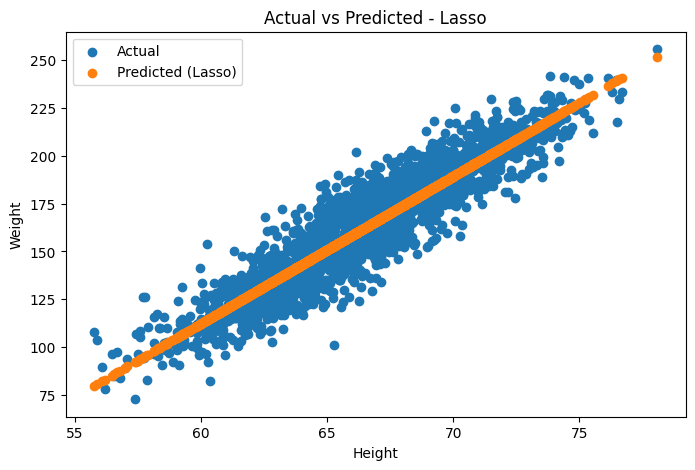

In [24]:
# Visualize 
# Actual V/S Ridge 
y_pred_ridge = lasso.predict(X_test)

plt.figure(figsize=(8,5))
plt.scatter(X_test["Height"], y_test, label="Actual")
plt.scatter(X_test["Height"], y_pred_ridge, label="Predicted (Lasso)")

plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Actual vs Predicted - Lasso")
plt.legend()
plt.show()
